# Smoke Detection IoT

This notebook analyzes the smoke detection IoT dataset before model training.

Only the needed columns are kept:

- `Temperature[C]`
- `Humidity[%]`
- `TVOC[ppb]`
- `eCO2[ppm]`
- `Fire Alarm`

These columns are renamed to simple ML-friendly names after loading the raw CSV.


#### 1. Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')


#### 2. Load Data


In [2]:
raw_smoke_data = pd.read_csv('smoke_detection_iot.csv')

print('Raw smoke dataset shape:', raw_smoke_data.shape)
display(raw_smoke_data.head())


Raw smoke dataset shape: (62630, 16)


,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
0,0,1654733331,20.000,57.36,0,400,12306,18520,939.735,0.0,0.0,0.0,0.0,0.0,0,0
1,1,1654733332,20.015,56.67,0,400,12345,18651,939.744,0.0,0.0,0.0,0.0,0.0,1,0
2,2,1654733333,20.029,55.96,0,400,12374,18764,939.738,0.0,0.0,0.0,0.0,0.0,2,0
3,3,1654733334,20.044,55.28,0,400,12390,18849,939.736,0.0,0.0,0.0,0.0,0.0,3,0
4,4,1654733335,20.059,54.69,0,400,12403,18921,939.744,0.0,0.0,0.0,0.0,0.0,4,0


#### 3. Keep Only Needed Columns and Rename Them

The raw dataset contains extra sensor columns that I do not need for this ML version. I will keep only the selected features and target label, then rename them for easier use.


In [3]:
columns_to_keep = ['Temperature[C]', 'Humidity[%]', 'TVOC[ppb]', 'eCO2[ppm]', 'Fire Alarm']

smoke_data_clean = raw_smoke_data[columns_to_keep].copy()

smoke_data_clean = smoke_data_clean.rename(columns={
    'Temperature[C]': 'temperature',
    'Humidity[%]': 'humidity',
    'TVOC[ppb]': 'tvoc_ppb',
    'eCO2[ppm]': 'eco2_ppm',
    'Fire Alarm': 'fire_alarm'
})

print('Smoke clean dataset shape after keeping needed columns:', smoke_data_clean.shape)

print('Easy-to-understand column names:')
print(smoke_data_clean.columns.tolist())

display(smoke_data_clean.head())


Smoke clean dataset shape after keeping needed columns: (62630, 5)
Easy-to-understand column names:
['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm', 'fire_alarm']


,temperature,humidity,tvoc_ppb,eco2_ppm,fire_alarm
0,20.000,57.36,0,400,0
1,20.015,56.67,0,400,0
2,20.029,55.96,0,400,0
3,20.044,55.28,0,400,0
4,20.059,54.69,0,400,0


#### 4. Add a Human-Readable Alarm Status Column

`fire_alarm` stays as the numeric target column for machine learning. `alarm_status` is only a readable label that helps with analysis, charts, and explanations.


In [4]:
smoke_data_clean['alarm_status'] = smoke_data_clean['fire_alarm'].map({
    0: 'No Smoke',
    1: 'Smoke'
})

print('Columns after adding readable label:')
print(smoke_data_clean.columns.tolist())

display(smoke_data_clean.head(10))


Columns after adding readable label:
['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm', 'fire_alarm', 'alarm_status']


,temperature,humidity,tvoc_ppb,eco2_ppm,fire_alarm,alarm_status
0,20.000,57.36,0,400,0,No Smoke
1,20.015,56.67,0,400,0,No Smoke
2,20.029,55.96,0,400,0,No Smoke
3,20.044,55.28,0,400,0,No Smoke
4,20.059,54.69,0,400,0,No Smoke
5,20.073,54.12,0,400,0,No Smoke
6,20.088,53.61,0,400,0,No Smoke
7,20.103,53.20,0,400,0,No Smoke
8,20.117,52.81,0,400,0,No Smoke
9,20.132,52.46,0,400,0,No Smoke


#### 5. Preprocessing: Export Clean Data to Formatted Excel

This step saves the cleaned dataframe as a new `.xlsx` file for viewing and sharing.

The original raw CSV is still kept unchanged. The model does not need to read this Excel file; the notebook continues using `smoke_data_clean` in memory.


In [ ]:
from openpyxl.styles import Font, PatternFill, Border, Side, Alignment
from openpyxl.utils import get_column_letter

excel_file_name = 'smoke_detection_clean_formatted.xlsx'

# Put columns in a clear order for Excel viewing.
excel_data = smoke_data_clean[[
    'temperature',
    'humidity',
    'tvoc_ppb',
    'eco2_ppm',
    'alarm_status',
    'fire_alarm'
]].copy()

with pd.ExcelWriter(excel_file_name, engine='openpyxl') as writer:
    excel_data.to_excel(writer, sheet_name='Clean Smoke Data', index=False)

    workbook = writer.book
    worksheet = writer.sheets['Clean Smoke Data']

    header_fill = PatternFill(start_color='1F4E78', end_color='1F4E78', fill_type='solid')
    header_font = Font(color='FFFFFF', bold=True)
    thin_gray_border = Border(
        left=Side(style='thin', color='D9E2F3'),
        right=Side(style='thin', color='D9E2F3'),
        top=Side(style='thin', color='D9E2F3'),
        bottom=Side(style='thin', color='D9E2F3')
    )

    # Style all cells and make the header stand out.
    for row in worksheet.iter_rows():
        for cell in row:
            cell.border = thin_gray_border
            cell.alignment = Alignment(vertical='center')
            if cell.row == 1:
                cell.fill = header_fill
                cell.font = header_font
                cell.alignment = Alignment(horizontal='center', vertical='center')

    # Set readable column widths.
    column_widths = {
        'A': 14,  # temperature
        'B': 12,  # humidity
        'C': 12,  # tvoc_ppb
        'D': 12,  # eco2_ppm
        'E': 16,  # alarm_status
        'F': 12   # fire_alarm
    }

    for column_letter, width in column_widths.items():
        worksheet.column_dimensions[column_letter].width = width

    # Freeze the header row and add filters.
    worksheet.freeze_panes = 'A2'
    worksheet.auto_filter.ref = worksheet.dimensions

    # Optional number formatting.
    for row in range(2, worksheet.max_row + 1):
        worksheet[f'A{row}'].number_format = '0.00'
        worksheet[f'B{row}'].number_format = '0.00'
        worksheet[f'C{row}'].number_format = '0'
        worksheet[f'D{row}'].number_format = '0'
        worksheet[f'F{row}'].number_format = '0'

print(f'Formatted Excel file saved as: {excel_file_name}')


#### 6. Initial Overview


In [ ]:
print('Data types and non-null values:')
smoke_data_clean.info()

smoke_data_clean.describe(include='all').round(2).T



Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   temperature   62630 non-null  float64
 1   humidity      62630 non-null  float64
 2   tvoc_ppb      62630 non-null  int64  
 3   eco2_ppm      62630 non-null  int64  
 4   fire_alarm    62630 non-null  int64  
 5   alarm_status  62630 non-null  object 
dtypes: float64(2), int64(3), object(1)
memory usage: 2.9+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
temperature,62630.0,NaN,NaN,NaN,15.97,14.36,-22.01,10.99,20.13,25.41,59.93
humidity,62630.0,NaN,NaN,NaN,48.54,8.87,10.74,47.53,50.15,53.24,75.2
tvoc_ppb,62630.0,NaN,NaN,NaN,1942.06,7811.59,0.0,130.0,981.0,1189.0,60000.0
eco2_ppm,62630.0,NaN,NaN,NaN,670.02,1905.89,400.0,400.0,400.0,438.0,60000.0
fire_alarm,62630.0,NaN,NaN,NaN,0.71,0.45,0.0,0.0,1.0,1.0,1.0
alarm_status,62630,2,Smoke,44757,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 7. Analysis: Duplicate and Missing Values


In [6]:
duplicate_rows_count = smoke_data_clean.duplicated().sum()
duplicate_rows_percent = duplicate_rows_count / len(smoke_data_clean) * 100

print(f'Duplicate rows after keeping selected columns: {duplicate_rows_count} ({duplicate_rows_percent:.2f}%)')

missing_values_count = smoke_data_clean.isna().sum()
missing_values_percent = smoke_data_clean.isna().mean() * 100
missing_values_summary = pd.DataFrame({
    'missing_count': missing_values_count,
    'missing_values_percent': missing_values_percent
}).sort_values('missing_values_percent', ascending=False)

display(missing_values_summary)


Duplicate rows after keeping selected columns: 41 (0.07%)


,missing_count,missing_values_percent
temperature,0,0.0
humidity,0,0.0
tvoc_ppb,0,0.0
eco2_ppm,0,0.0
fire_alarm,0,0.0
alarm_status,0,0.0


#### 8. Target Check


,count,percent
fire_alarm,,
Normal,17873,28.54%
Fire,44757,71.46%


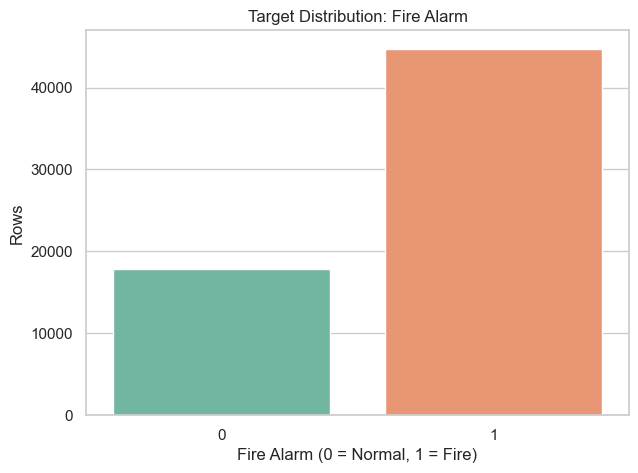

In [7]:
fire_alarm_counts = smoke_data_clean['fire_alarm'].value_counts().sort_index()
fire_alarm_percent = smoke_data_clean['fire_alarm'].value_counts(normalize=True).sort_index() * 100

fire_alarm_summary = pd.DataFrame({
    'count': fire_alarm_counts,
    'percent': fire_alarm_percent.map(lambda value: f'{value:.2f}%')
})
fire_alarm_summary.index = fire_alarm_summary.index.map({0: 'Normal', 1: 'Fire'})

display(fire_alarm_summary)

plt.figure(figsize=(7, 5))
sns.countplot(data=smoke_data_clean, x='fire_alarm', hue='fire_alarm', palette='Set2', legend=False)
plt.title('Target Distribution: Fire Alarm')
plt.xlabel('Fire Alarm (0 = Normal, 1 = Fire)')
plt.ylabel('Rows')
plt.show()


#### 9. Feature Summary


In [8]:
sensor_feature_columns = ['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm']

smoke_data_clean[sensor_feature_columns].describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
temperature,62630.0,15.97,14.36,-22.01,10.99,20.13,25.41,59.93
humidity,62630.0,48.54,8.87,10.74,47.53,50.15,53.24,75.20
tvoc_ppb,62630.0,1942.06,7811.59,0.00,130.00,981.00,1189.00,60000.00
eco2_ppm,62630.0,670.02,1905.89,400.00,400.00,400.00,438.00,60000.00


#### 10. Feature Distributions


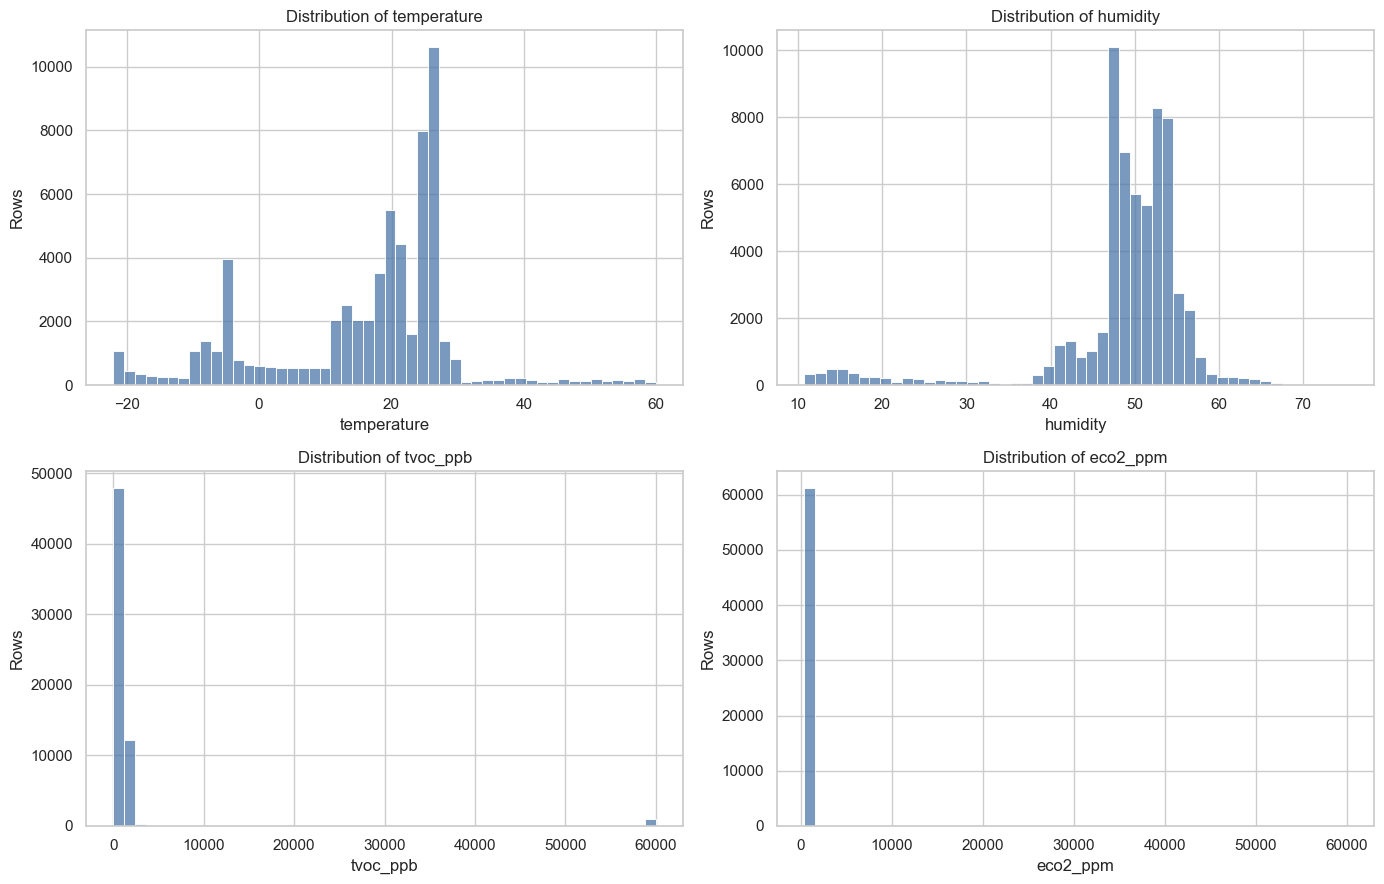

In [9]:
sensor_feature_columns = ['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, column in zip(axes, sensor_feature_columns):
    sns.histplot(data=smoke_data_clean, x=column, bins=50, ax=ax, color='#4C78A8')
    ax.set_title(f'Distribution of {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Rows')

plt.tight_layout()
plt.show()


#### 11. Class-wise Feature Comparison


In [10]:
feature_summary_by_fire_alarm = smoke_data_clean.groupby('fire_alarm')[sensor_feature_columns].agg(['min', 'median', 'mean', 'max']).T
feature_summary_by_fire_alarm.columns = ['Normal', 'Fire']
display(feature_summary_by_fire_alarm)


Normal          Fire
temperature min       -22.010000    -22.010000
            median     20.540000     20.020000
            mean       19.694803     14.483152
            max        59.930000     41.410000
humidity    min        10.740000     13.360000
            median     46.140000     51.400000
            mean       42.930077     50.779534
            max        75.200000     70.280000
tvoc_ppb    min         0.000000      0.000000
            median     86.000000   1103.000000
            mean     4596.587255    882.013071
            max     60000.000000  18062.000000
eco2_ppm    min       400.000000    400.000000
            median    400.000000    404.000000
            mean      962.587255    553.189356
            max     39185.000000  60000.000000

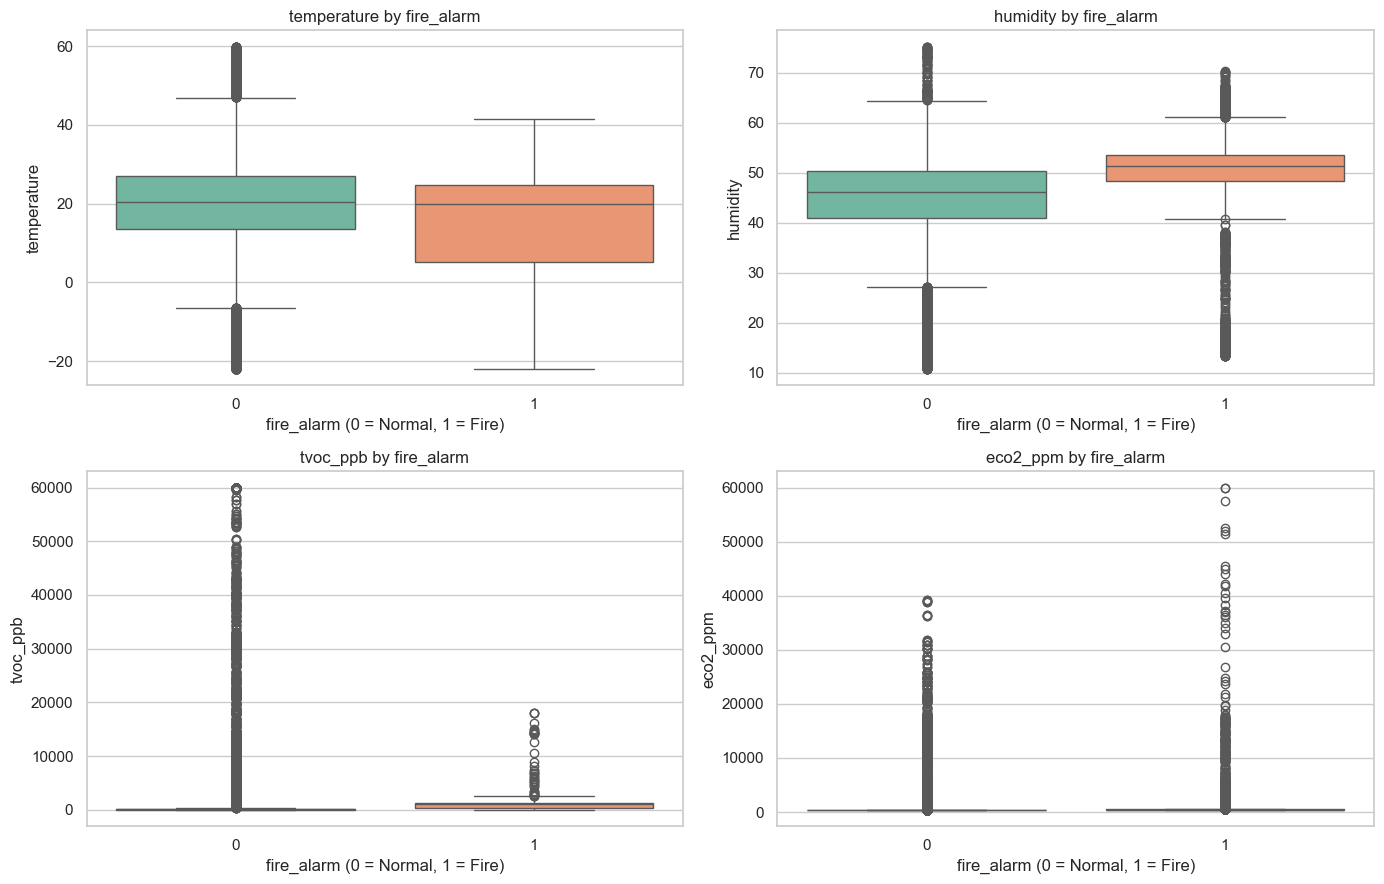

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, column in zip(axes, sensor_feature_columns):
    sns.boxplot(data=smoke_data_clean, x='fire_alarm', y=column, hue='fire_alarm', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'{column} by fire_alarm')
    ax.set_xlabel('fire_alarm (0 = Normal, 1 = Fire)')

plt.tight_layout()
plt.show()


#### 12. Outlier Analysis Using IQR


In [12]:
outlier_analysis_rows = []

for column in sensor_feature_columns:
    q1 = smoke_data_clean[column].quantile(0.25)
    q3 = smoke_data_clean[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((smoke_data_clean[column] < lower_bound) | (smoke_data_clean[column] > upper_bound)).sum()
    outlier_analysis_rows.append({
        'feature': column,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': outlier_count,
        'outlier_percent': outlier_count / len(smoke_data_clean) * 100
    })

iqr_outlier_summary = pd.DataFrame(outlier_analysis_rows)
display(iqr_outlier_summary)


,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent
0,temperature,10.99425,25.4095,14.41525,-10.628625,47.032375,3908,6.239821
1,humidity,47.53000,53.2400,5.71000,38.965000,61.805000,5083,8.115919
2,tvoc_ppb,130.00000,1189.0000,1059.00000,-1458.500000,2777.500000,2463,3.932620
3,eco2_ppm,400.00000,438.0000,38.00000,343.000000,495.000000,12076,19.281494


#### 13. Correlation Analysis


,temperature,humidity,tvoc_ppb,eco2_ppm,fire_alarm
temperature,1.000000,-0.243986,0.082442,0.079265,-0.163902
humidity,-0.243986,1.000000,-0.488878,-0.369095,0.399846
tvoc_ppb,0.082442,-0.488878,1.000000,0.606118,-0.214743
eco2_ppm,0.079265,-0.369095,0.606118,1.000000,-0.097006
fire_alarm,-0.163902,0.399846,-0.214743,-0.097006,1.000000


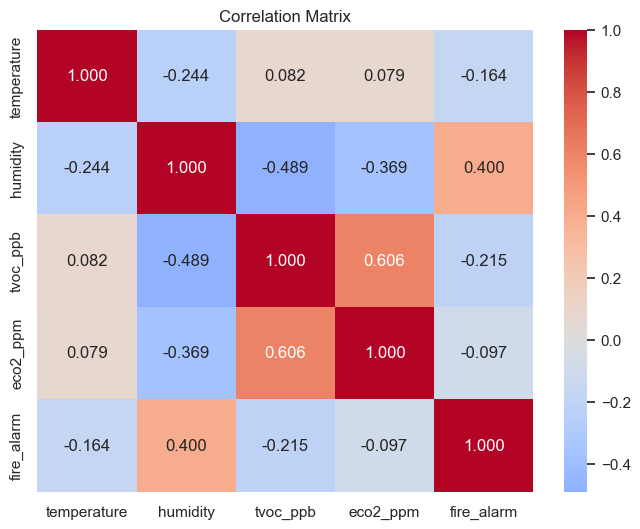

In [13]:
correlation_columns_to_check = sensor_feature_columns + ['fire_alarm']
sensor_correlation_matrix = smoke_data_clean[correlation_columns_to_check].corr(numeric_only=True)

display(sensor_correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(sensor_correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Matrix')
plt.show()


#### 14. Analysis Takeaways

So far we have done the first cleaning step and several analysis checks:

- Kept only the needed columns.
- Renamed columns to easy names.
- Checked missing values and duplicate rows.
- Checked the target distribution.
- Compared sensor values between normal and fire rows.
- Checked outliers with IQR.
- Checked correlation between features and the target.

Before modeling, we should prepare the final feature matrix and target variable, then split the data into training and testing sets.


#### 15. Preprocessing: Prepare Features and Target

Here we separate the input sensor features from the target label. This does not train a model yet; it only prepares the data for the next step.


In [14]:
features_col = smoke_data_clean[['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm']]
target_col = smoke_data_clean['fire_alarm']

print('Feature column shape:', features_col.shape)
print('Target column shape:', target_col.shape)

display(features_col.head())
display(target_col.head())


Feature column shape: (62630, 4)
Target column shape: (62630,)


,temperature,humidity,tvoc_ppb,eco2_ppm
0,20.000,57.36,0,400
1,20.015,56.67,0,400
2,20.029,55.96,0,400
3,20.044,55.28,0,400
4,20.059,54.69,0,400


0    0
1    0
2    0
3    0
4    0
Name: fire_alarm, dtype: int64

#### 16. Preprocessing: Train and Test Split

We use a stratified split so the training and testing data keep the same normal/fire ratio.


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_col,
    target_col,
    test_size=0.2,
    random_state=42,
    stratify=target_col
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

print('\nTraining target distribution:')
display((y_train.value_counts(normalize=True).sort_index() * 100).map(lambda value: f'{value:.2f}%'))

print('\nTesting target distribution:')
display((y_test.value_counts(normalize=True).sort_index() * 100).map(lambda value: f'{value:.2f}%'))


X_train: (50104, 4)
X_test: (12526, 4)
y_train: (50104,)
y_test: (12526,)

Training target distribution:


fire_alarm
0    28.54%
1    71.46%
Name: proportion, dtype: object


Testing target distribution:


fire_alarm
0    28.54%
1    71.46%
Name: proportion, dtype: object

#### 17. Preprocessing: Scale Sensor Features

Scaling helps many ML models compare the sensor columns fairly, especially because `tvoc_ppb` and `eco2_ppm` can be much larger than temperature and humidity.


In [16]:
from sklearn.preprocessing import StandardScaler

sensor_scaler = StandardScaler()

X_train_scaled = sensor_scaler.fit_transform(X_train)
X_test_scaled = sensor_scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features_col.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features_col.columns, index=X_test.index)

display(X_train_scaled.head())


,temperature,humidity,tvoc_ppb,eco2_ppm
17799,0.102304,0.380413,-0.104938,-0.140638
6596,-1.577382,0.827065,-0.222397,-0.140638
46619,0.765904,-0.094579,-0.078248,-0.137486
41355,0.619645,0.414422,-0.094881,-0.134335
57343,0.466351,-0.914197,-0.240447,-0.140638


#### 18. Evaluate Baseline Model

Logistic Regression is used as the baseline model. A baseline model is the first simple model we train so we have something to compare against later.

For smoke detection, accuracy is useful, but recall and F1-score are more important because we do not want the model to miss real smoke cases.


Accuracy:  77.51%
Precision: 76.94%
Recall:    97.87%
F1-score:  86.15%

Classification report:
              precision    recall  f1-score   support

    No Smoke       0.83      0.27      0.40      3575
       Smoke       0.77      0.98      0.86      8951

    accuracy                           0.78     12526
   macro avg       0.80      0.62      0.63     12526
weighted avg       0.79      0.78      0.73     12526



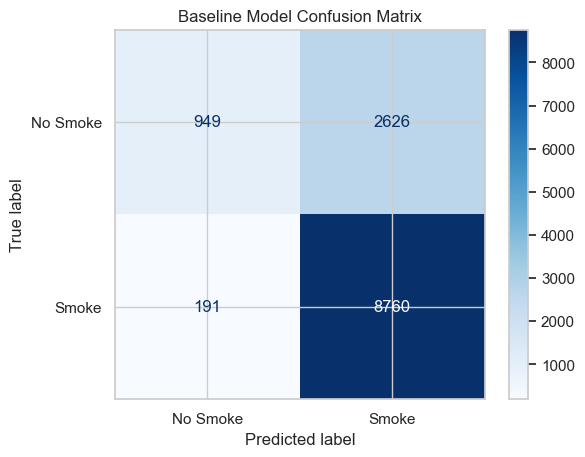

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

baseline_predictions = baseline_model.predict(X_test_scaled)

baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_precision = precision_score(y_test, baseline_predictions)
baseline_recall = recall_score(y_test, baseline_predictions)
baseline_f1 = f1_score(y_test, baseline_predictions)

print(f'Accuracy:  {baseline_accuracy:.2%}')
print(f'Precision: {baseline_precision:.2%}')
print(f'Recall:    {baseline_recall:.2%}')
print(f'F1-score:  {baseline_f1:.2%}')

print('\nClassification report:')
print(classification_report(y_test, baseline_predictions, target_names=['No Smoke', 'Smoke']))

baseline_confusion_matrix = confusion_matrix(y_test, baseline_predictions)
ConfusionMatrixDisplay(baseline_confusion_matrix, display_labels=['No Smoke', 'Smoke']).plot(cmap='Blues')
plt.title('Baseline Model Confusion Matrix')
plt.show()


#### 19. Train and Compare More Models

Now we train a few different classification models and compare them using the same test data.

The models are:

- Logistic Regression: simple baseline model
- Decision Tree: easy to understand, but can overfit
- Random Forest: stronger tree-based model
- KNN: predicts based on nearby similar rows
- Linear SVM: finds a straight boundary between classes


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Linear SVM': LinearSVC(max_iter=5000, random_state=42)
}

model_results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    
    trained_models[model_name] = model
    model_results.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, predictions),
        'precision': precision_score(y_test, predictions, zero_division=0),
        'recall': recall_score(y_test, predictions, zero_division=0),
        'f1_score': f1_score(y_test, predictions, zero_division=0)
    })

model_results = pd.DataFrame(model_results)
model_results = model_results.sort_values(by='f1_score', ascending=False)

display(model_results.style.format({
    'accuracy': '{:.2%}',
    'precision': '{:.2%}',
    'recall': '{:.2%}',
    'f1_score': '{:.2%}'
}))


,model,accuracy,precision,recall,f1_score
2,Random Forest,99.70%,99.71%,99.87%,99.79%
1,Decision Tree,99.58%,99.71%,99.71%,99.71%
3,KNN,99.20%,99.12%,99.77%,99.44%
0,Logistic Regression,77.51%,76.94%,97.87%,86.15%
4,Linear SVM,75.61%,75.35%,97.89%,85.15%


#### 20. Choose Best Model

The best model is selected using `f1_score` because it balances precision and recall.

For this smoke detection problem, recall is especially important because a false negative means the model missed a real smoke case. However, F1-score is a good general choice because it checks both missed smoke cases and false alarms.


Best model: Random Forest
Best F1-score: 99.79%

Classification report for best model:
              precision    recall  f1-score   support

    No Smoke       1.00      0.99      0.99      3575
       Smoke       1.00      1.00      1.00      8951

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526



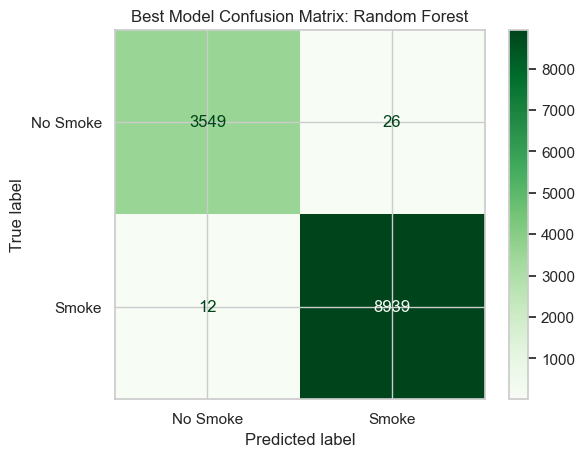

In [20]:
best_model_name = model_results.iloc[0]['model']
best_model = trained_models[best_model_name]

best_predictions = best_model.predict(X_test_scaled)

print('Best model:', best_model_name)
print(f"Best F1-score: {model_results.iloc[0]['f1_score']:.2%}")

print('\nClassification report for best model:')
print(classification_report(y_test, best_predictions, target_names=['No Smoke', 'Smoke']))

best_confusion_matrix = confusion_matrix(y_test, best_predictions)
ConfusionMatrixDisplay(best_confusion_matrix, display_labels=['No Smoke', 'Smoke']).plot(cmap='Greens')
plt.title(f'Best Model Confusion Matrix: {best_model_name}')
plt.show()


#### 21. Final Conclusion

In this notebook, we completed the main ML pipeline:

- Loaded the smoke detection dataset
- Kept only the needed columns
- Renamed columns to simple names
- Added a readable `alarm_status` column
- Checked missing values and duplicates
- Explored the target and sensor features
- Split the data into training and testing sets
- Scaled the sensor features
- Trained a baseline Logistic Regression model
- Compared multiple classification models
- Selected the best model based on F1-score

The final model should be judged mainly by recall and F1-score for the `Smoke` class. High recall means the model catches most smoke cases, while F1-score gives a balanced view of missed smoke cases and false alarms.
